In [13]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [14]:
import pandas as pd
import numpy as np
import glob
from scipy.signal import find_peaks, peak_prominences
import time
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, date
from collections import defaultdict
import random
import geopandas as gpd
import mapclassify

## File sizes over time

### events

In [15]:
# extract the file size from the file name,

directory = r"D:\gdelt_data"
years = range(2016, 2026)
file_sizes = []
days = []
for year in years:
    start = time.time()

    year_dir = os.path.join(directory, str(year) + "_events")
    #print(year_dir)
    file_pattern = os.path.join(year_dir, "*.export.CSV.zip")
    files = sorted(glob.glob(file_pattern))

    for file in files:
        date_ = file[26:34] # convert to datetime:
        dt = datetime.strptime(date_, "%Y%m%d").date()

        size_bytes = os.path.getsize(file)
        size_gb = size_bytes / (1024 ** 3)

        file_sizes.append({
            "year": year,
            "file": os.path.basename(file),
            "size_gb": size_gb,
            "date": dt
        })

    print(f"Processed year {year}: {len(files)} files in {time.time() - start:.2f} seconds.")

Processed year 2016: 366 files in 40.85 seconds.
Processed year 2017: 365 files in 38.79 seconds.
Processed year 2018: 365 files in 39.12 seconds.
Processed year 2019: 365 files in 43.07 seconds.
Processed year 2020: 366 files in 44.76 seconds.
Processed year 2021: 365 files in 45.37 seconds.
Processed year 2022: 364 files in 45.47 seconds.
Processed year 2023: 364 files in 47.77 seconds.
Processed year 2024: 366 files in 47.95 seconds.
Processed year 2025: 347 files in 42.65 seconds.


In [16]:
#file_sizes_df = pd.DataFrame(file_sizes)
#file_sizes_df.to_csv("gdelt_event_file_sizes.csv", index=False)

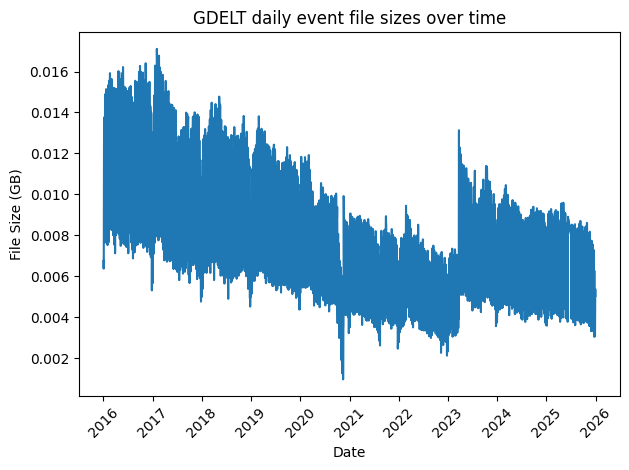

In [17]:
sizes_gb = [file_sizes[i]['size_gb'] for i in range(len(file_sizes))]
dates = [file_sizes[i]['date'] for i in range(len(file_sizes))]
plt.plot(dates, sizes_gb)
plt.title("GDELT daily event file sizes over time")
plt.xlabel("Date")
plt.ylabel("File Size (GB)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#where does the big jump around 2023 come from?

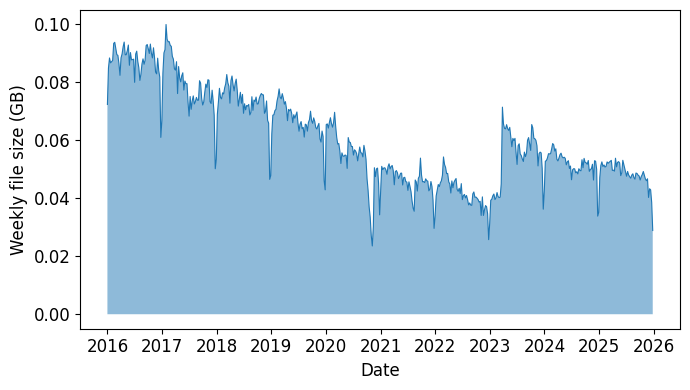

In [19]:
# aggregate by week
weekly_sizes = []
weekly_dates = [] 
for i in range(0, len(file_sizes), 7):
    week_files = file_sizes[i:i+7]
    week_size = sum([f['size_gb'] for f in week_files])
    weekly_sizes.append(week_size)
    weekly_dates.append(week_files[0]['date']) #first day of the week

#plt.plot(weekly_dates, weekly_sizes)
plt.figure(figsize=(7, 4))

plt.fill_between(
    weekly_dates,
    weekly_sizes,
    alpha=0.5
)

plt.plot(
    weekly_dates,
    weekly_sizes,
    linewidth=0.8
)

plt.xlabel("Date", fontsize=12)
plt.ylabel("Weekly file size (GB)", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

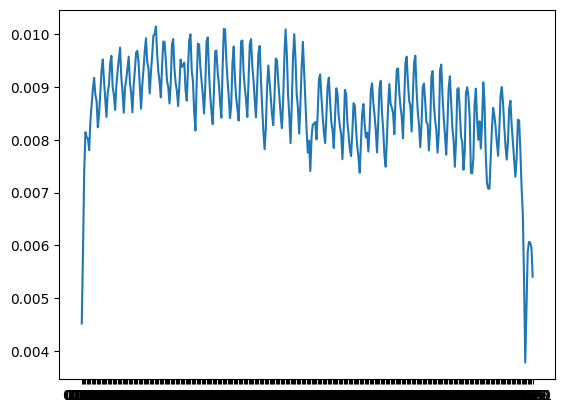

In [8]:
daily_stats = defaultdict(lambda: {
    "total_size": 0.0,
    "count": 0
})

for item in file_sizes:
    month_day = item["date"].strftime("%m-%d")

    daily_stats[month_day]["total_size"] += item["size_gb"]
    daily_stats[month_day]["count"] += 1

# Calculate the mean size for each day
daily_means = {day: stats["total_size"] / stats["count"] for day, stats in daily_stats.items()}

plt.plot(list(daily_means.keys()), list(daily_means.values()))

### mentions

In [9]:
"""
directory = r"D:\gdelt_data"
years = range(2016, 2017)
file_sizes = []
days = []
for year in years:
    start = time.time()

    year_dir = os.path.join(directory, str(year) + "_mentions")
    #print(year_dir)
    file_pattern = os.path.join(year_dir, "*.mentions.CSV.zip")
    files = sorted(glob.glob(file_pattern))

    for file in files:
        date_ = file[28:40] # convert to datetime:
        print(file, date_)
        dt = datetime.strptime(date_, "%Y%m%d%H%M")

        size_bytes = os.path.getsize(file)
        size_gb = size_bytes / (1024 ** 3)

        file_sizes.append({
            "year": year,
            "file": os.path.basename(file),
            "size_gb": size_gb,
            "date": dt
        })

    print(f"Processed year {year}: {len(files)} files in {time.time() - start:.2f} seconds.")

mentions_df = pd.DataFrame(file_sizes)
mentions_df.to_csv("gdelt_2016_mentions_file_sizes.csv", index=False)
"""

'\ndirectory = r"D:\\gdelt_data"\nyears = range(2016, 2017)\nfile_sizes = []\ndays = []\nfor year in years:\n    start = time.time()\n\n    year_dir = os.path.join(directory, str(year) + "_mentions")\n    #print(year_dir)\n    file_pattern = os.path.join(year_dir, "*.mentions.CSV.zip")\n    files = sorted(glob.glob(file_pattern))\n\n    for file in files:\n        date_ = file[28:40] # convert to datetime:\n        print(file, date_)\n        dt = datetime.strptime(date_, "%Y%m%d%H%M")\n\n        size_bytes = os.path.getsize(file)\n        size_gb = size_bytes / (1024 ** 3)\n\n        file_sizes.append({\n            "year": year,\n            "file": os.path.basename(file),\n            "size_gb": size_gb,\n            "date": dt\n        })\n\n    print(f"Processed year {year}: {len(files)} files in {time.time() - start:.2f} seconds.")\n\nmentions_df = pd.DataFrame(file_sizes)\nmentions_df.to_csv("gdelt_2016_mentions_file_sizes.csv", index=False)\n'

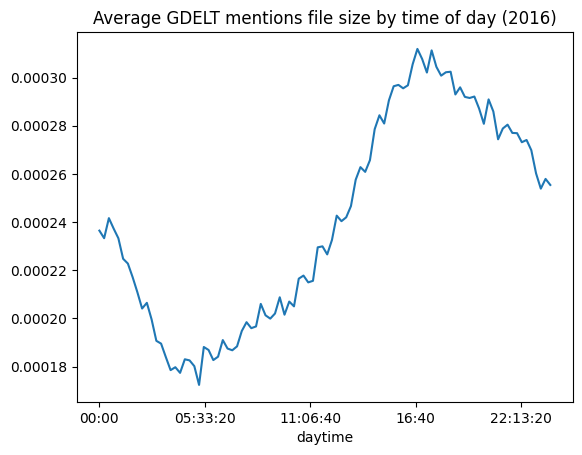

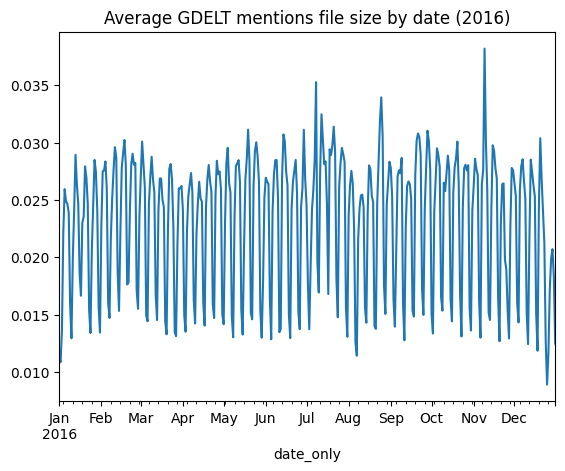

In [10]:
mentions_df = pd.read_csv("gdelt_2016_mentions_file_sizes.csv")

mentions_df['date'] = pd.to_datetime(mentions_df['date'])

mentions_df['daytime'] = mentions_df['date'].dt.time
mentions_df['date_only'] = mentions_df['date'].dt.normalize()

mentions_df.groupby('daytime')['size_gb'].mean().plot()
plt.title("Average GDELT mentions file size by time of day (2016)")
plt.show()
mentions_df.groupby('date_only')['size_gb'].sum().plot()
plt.title("Average GDELT mentions file size by date (2016)")
plt.show()

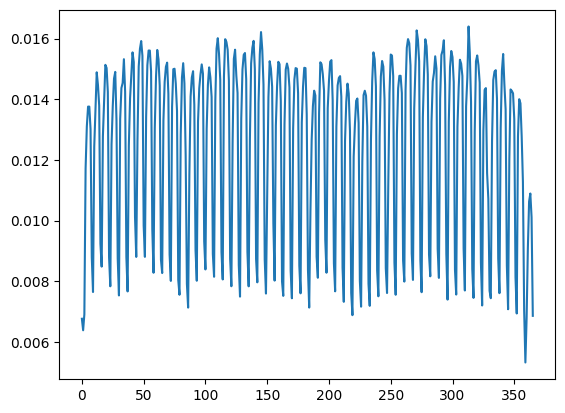

In [11]:
file_sizes_df = pd.read_csv("gdelt_event_file_sizes.csv")
plt.plot(file_sizes_df[file_sizes_df['date'] <= '2016-12-31']['size_gb'])

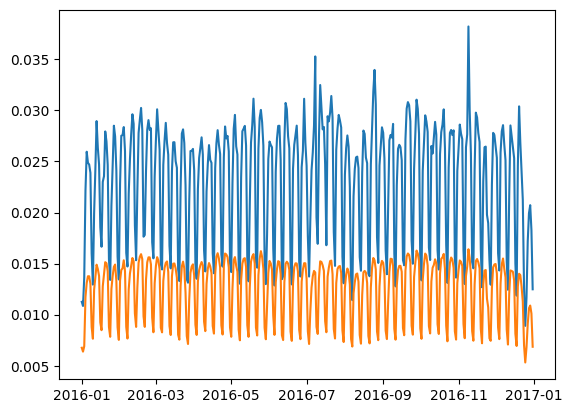

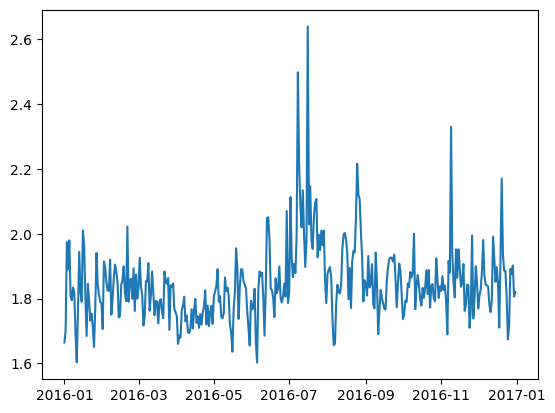

In [12]:
mentions = mentions_df.groupby('date_only')['size_gb'].sum()
events = file_sizes_df[file_sizes_df['date'] <= '2016-12-31']['size_gb']

plt.plot(mentions.index, mentions.values, label='Mentions')
plt.plot(mentions.index, events.values, label='Events')
plt.show()
plt.plot(mentions.index,mentions.values/events.values, label='Ratio')
plt.show()

In [13]:
# build dataset of all events in 2016:
"""
year = 2025

start = date(year, 1, 1)
end = date(year, 12, 31)

base = "http://data.gdeltproject.org/events/"
current = start
all_events_year = []

while current <= end:
    #time.sleep(0.5)
    start = time.time()
    datestr = current.strftime("%Y%m%d")
    directory = f"D:\\gdelt_data\\{year}_events\\{datestr}.export.CSV.zip"
    # import data from directory zip file:
    if os.path.exists(directory):
        df = pd.read_csv(directory, compression='zip', header=None, sep='\t', low_memory=False, nrows=10000)
        df = df.sample(n=min(100, len(df)), random_state=42)
        all_events_year.append(df)
    print(f"Processed {current} in {time.time() - start:.2f} seconds.")

    current += timedelta(days=1)

start = time.time()
concat_events_year = pd.concat(all_events_year, ignore_index=True)
print(f"Concatenated events in {time.time() - start:.2f} seconds.")
concat_events_year.to_csv(f"gdelt_all_events_{year}_sample.csv", index=False)
"""

'\nyear = 2025\n\nstart = date(year, 1, 1)\nend = date(year, 12, 31)\n\nbase = "http://data.gdeltproject.org/events/"\ncurrent = start\nall_events_year = []\n\nwhile current <= end:\n    #time.sleep(0.5)\n    start = time.time()\n    datestr = current.strftime("%Y%m%d")\n    directory = f"D:\\gdelt_data\\{year}_events\\{datestr}.export.CSV.zip"\n    # import data from directory zip file:\n    if os.path.exists(directory):\n        df = pd.read_csv(directory, compression=\'zip\', header=None, sep=\'\t\', low_memory=False, nrows=10000)\n        df = df.sample(n=min(100, len(df)), random_state=42)\n        all_events_year.append(df)\n    print(f"Processed {current} in {time.time() - start:.2f} seconds.")\n\n    current += timedelta(days=1)\n\nstart = time.time()\nconcat_events_year = pd.concat(all_events_year, ignore_index=True)\nprint(f"Concatenated events in {time.time() - start:.2f} seconds.")\nconcat_events_year.to_csv(f"gdelt_all_events_{year}_sample.csv", index=False)\n'

The column names are taken from the Codebook:
http://data.gdeltproject.org/documentation/GDELT-Event_Codebook-V2.0.pdf
The columns for the ADM2Codes were removed

In [14]:
column_names = ["GlobalEventID", "Day", "MonthYear", "Year", "FractionDate", "Actor1Code", "Actor1Name", "Actor1CountryCode", "Actor1KnownGroupCode", "Actor1EthnicCode", "Actor1Religion1Code", 
                "Actor1Religion2Code", "Actor1Type1Code", "Actor1Type2Code", "Actor1Type3Code", "Actor2Code", "Actor2Name", "Actor2CountryCode", "Actor2KnownGroupCode", "Actor2EthnicCode", 
                "Actor2Religion1Code", "Actor2Religion2Code", "Actor2Type1Code", "Actor2Type2Code", "Actor2Type3Code", "IsRootEvent", "EventCode", "EventBaseCode", "EventRootCode", 
                "QuadClass", "GoldsteinScale", "NumMentions", "NumSources", "NumArticles", "AvgTone", 
                "Actor1Geo_Type", "Actor1Geo_FullName", "Actor1Geo_CountryCode", "Actor1Geo_ADM1Code", "Actor1Geo_Lat", "Actor1Geo_Long", "Actor1Geo_FeatureID", 
                "Actor2Geo_Type", "Actor2Geo_FullName", "Actor2Geo_CountryCode", "Actor2Geo_ADM1Code", "Actor2Geo_Lat", "Actor2Geo_Long", "Actor2Geo_FeatureID", 
                "ActionGeo_Type", "ActionGeo_FullName", "ActionGeo_CountryCode", "ActionGeo_ADM1Code", "ActionGeo_Lat", "ActionGeo_Long", "ActionGeo_FeatureID", 
                "DATEADDED", "SOURCEURL"]

#replace column names in the csv file with the above list:
sample_df = pd.read_csv("gdelt_all_events_2016_sample.csv", header=None)
# drop first row:
sample_df = sample_df.drop(0)
sample_df.columns = column_names
sample_df.head()

C:\Users\cgl_0\AppData\Local\Temp\ipykernel_28876\3339648045.py:11: DtypeWarning: Columns (0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 25, 6: 26, 7: 27, 8: 28, 9: 29, 10: 30, 11: 31, 12: 32, 13: 33, 14: 34, 15: 35, 16: 39, 17: 40, 18: 42, 19: 46, 20: 47, 21: 49, 22: 53, 23: 54, 24: 56) have mixed types. Specify dtype option on import or set low_memory=False.
  sample_df = pd.read_csv("gdelt_all_events_2016_sample.csv", header=None)


,GlobalEventID,Day,MonthYear,Year,FractionDate,Actor1Code,Actor1Name,Actor1CountryCode,Actor1KnownGroupCode,Actor1EthnicCode,...,Actor2Geo_FeatureID,ActionGeo_Type,ActionGeo_FullName,ActionGeo_CountryCode,ActionGeo_ADM1Code,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL
1,498562022,20160101,201601,2016,2016.0027,COP,POLICE CHIEF,NaN,NaN,NaN,...,601959,3,"Clark University, Massachusetts, United States",US,USMA,42.252,-71.8226,601959,20160101,http://www.telegram.com/article/20151231/NEWS/...
2,498559745,20160101,201601,2016,2016.0027,PSE,WEST BANK,PSE,NaN,NaN,...,NaN,4,"Ramallah, West Bank (general), West Bank",WE,WE00,31.9026,35.1955,-795956,20160101,http://www.maannews.com/Content.aspx?id=769603
3,498555895,20160101,201601,2016,2016.0027,JUD,JUDGE,NaN,NaN,NaN,...,-2601889,4,"London, London, City of, United Kingdom",UK,UKH9,51.5,-0.116667,-2601889,20160101,http://www.gazetteherald.co.uk/news/national/1...
4,498559803,20160101,201601,2016,2016.0027,RUS,RUSSIA,RUS,NaN,NaN,...,NaN,1,United States,US,US,38.0,-97.0,US,20160101,http://www.sott.net/article/309549-Foreshadowi...
5,498559582,20160101,201601,2016,2016.0027,MDV,MALE,MDV,NaN,NaN,...,NaN,2,"New Hampshire, United States",US,USNH,43.4108,-71.5653,NH,20160101,http://www.voanews.com/content/economy-more-th...


In [15]:
for year in range(2025, 2026):
    df = pd.read_csv(f"gdelt_all_events_{year}_sample.csv", header=None)
    df = df.drop(0)
    df.columns = column_names
    df.to_csv(f"gdelt_all_events_{year}_sample.csv", index=False)

C:\Users\cgl_0\AppData\Local\Temp\ipykernel_28876\427272259.py:2: DtypeWarning: Columns (0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 14, 6: 25, 7: 26, 8: 27, 9: 28, 10: 29, 11: 30, 12: 31, 13: 32, 14: 33, 15: 34, 16: 35, 17: 39, 18: 40, 19: 42, 20: 46, 21: 47, 22: 49, 23: 53, 24: 54, 25: 56) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"gdelt_all_events_{year}_sample.csv", header=None)


In [16]:
pd.read_csv("gdelt_all_events_2018_sample.csv", low_memory=False).head()

,GlobalEventID,Day,MonthYear,Year,FractionDate,Actor1Code,Actor1Name,Actor1CountryCode,Actor1KnownGroupCode,Actor1EthnicCode,...,Actor2Geo_FeatureID,ActionGeo_Type,ActionGeo_FullName,ActionGeo_CountryCode,ActionGeo_ADM1Code,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL
0,719033241,20180101,201801,2018,2018.0027,NGA,ABUJA,NGA,NaN,NaN,...,-1997013,4,"Abuja, Abuja Federal Capital Territory, Nigeria",NI,NI11,9.08333,7.53333,-1997013,20180101,https://www.msn.com/en-za/news/other/bad-econo...
1,719031033,20180101,201801,2018,2018.0027,JUD,DISTRICT COURT,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,20180101,https://www.hometownsource.com/abc_newspapers/...
2,719026600,20180101,201801,2018,2018.0027,PHL,FILIPINO,PHL,NaN,NaN,...,-2424066,4,"Davao, Davao City, Philippines",RP,RPC3,7.07306,125.61300,-2424066,20180101,http://newsinfo.inquirer.net/956585/filipinos-...
3,719031091,20180101,201801,2018,2018.0027,MED,SPOKESMAN,NaN,NaN,NaN,...,-2291861,4,"Lusaka, Lusaka, Zambia",ZA,ZA09,-15.41670,28.28330,-2291861,20180101,http://en.brinkwire.com/60169/zambia-president...
4,719030870,20180101,201801,2018,2018.0027,GOV,ENVOY,NaN,NaN,NaN,...,1661377,3,"San Diego, California, United States",US,USCA,32.71530,-117.15700,1661377,20180101,http://www.dailymail.co.uk/wires/ap/article-52...


In [17]:
sample_df.columns
# density plots for NumMentions, Numsources, NumArticles, AvgTone, GoldsteinScale, Lat, Long

Index(['GlobalEventID', 'Day', 'MonthYear', 'Year', 'FractionDate',
       'Actor1Code', 'Actor1Name', 'Actor1CountryCode', 'Actor1KnownGroupCode',
       'Actor1EthnicCode', 'Actor1Religion1Code', 'Actor1Religion2Code',
       'Actor1Type1Code', 'Actor1Type2Code', 'Actor1Type3Code', 'Actor2Code',
       'Actor2Name', 'Actor2CountryCode', 'Actor2KnownGroupCode',
       'Actor2EthnicCode', 'Actor2Religion1Code', 'Actor2Religion2Code',
       'Actor2Type1Code', 'Actor2Type2Code', 'Actor2Type3Code', 'IsRootEvent',
       'EventCode', 'EventBaseCode', 'EventRootCode', 'QuadClass',
       'GoldsteinScale', 'NumMentions', 'NumSources', 'NumArticles', 'AvgTone',
       'Actor1Geo_Type', 'Actor1Geo_FullName', 'Actor1Geo_CountryCode',
       'Actor1Geo_ADM1Code', 'Actor1Geo_Lat', 'Actor1Geo_Long',
       'Actor1Geo_FeatureID', 'Actor2Geo_Type', 'Actor2Geo_FullName',
       'Actor2Geo_CountryCode', 'Actor2Geo_ADM1Code', 'Actor2Geo_Lat',
       'Actor2Geo_Long', 'Actor2Geo_FeatureID', 'ActionGeo_

In [18]:
#pd.concat(all_events_2016[0:10], ignore_index=True)

In [19]:
#len(all_events_2016)
# concatenate all dataframes into one:
#pd.concat(all_events_2016, ignore_index=True)

#concat_events_2016 = pd.concat(all_events_2016, ignore_index=True)

## Density plots

In [20]:
import seaborn as sns

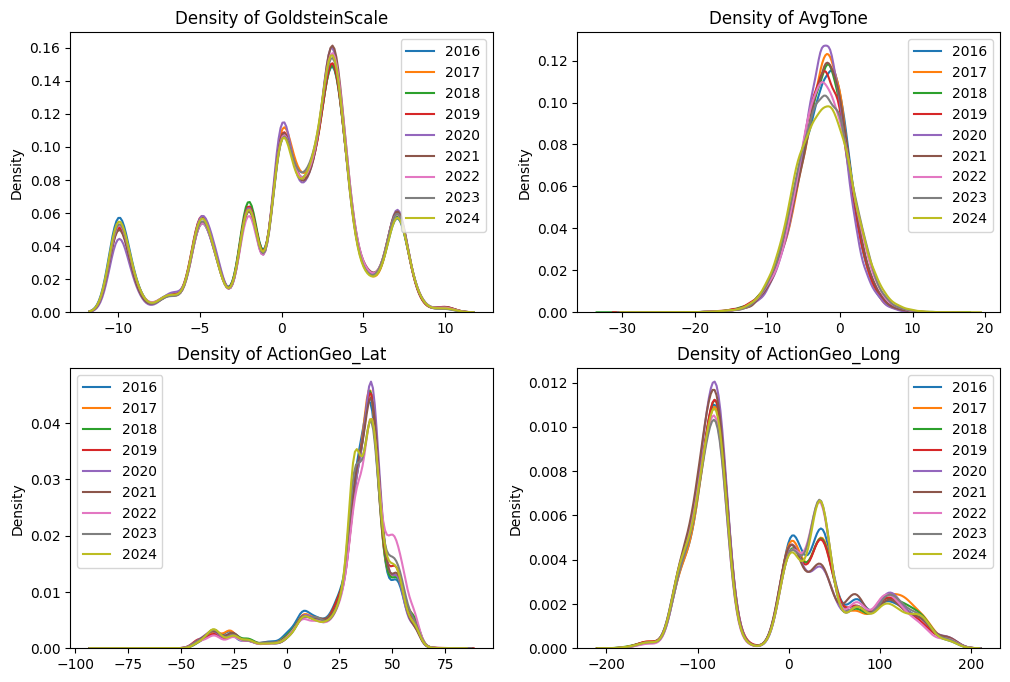

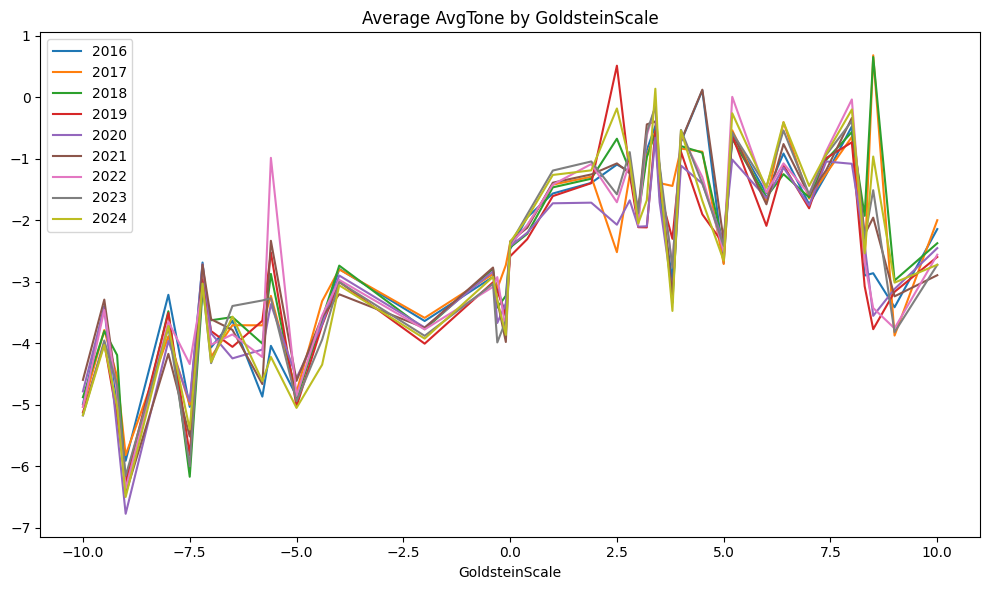

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

features = [
    "GoldsteinScale",
    "AvgTone",
    "ActionGeo_Lat",
    "ActionGeo_Long"
]

# separate figures for other plots
#fig_scatter, ax_scatter = plt.subplots(figsize=(8, 6))

fig_goldstein_mean, ax_goldstein_mean = plt.subplots(figsize=(10, 6))

#fig_goldstein_count, ax_goldstein_count = plt.subplots(figsize=(12, 6))

for year in range(2016, 2025):

    sample_df = pd.read_csv(
        f"gdelt_all_events_{year}_sample.csv",
        low_memory=False
    )

    df2 = sample_df[features]

    # KDE plots
    for i, var in enumerate(features):

        data = df2[var].dropna().to_numpy()

        sns.kdeplot(
            data,
            ax=axes[i],
            label=str(year)
        )

        axes[i].set_title(f"Density of {var}")

    # scatter plot
    #ax_scatter.scatter(
    #    df2["ActionGeo_Long"],
    #    df2["ActionGeo_Lat"],
    #    alpha=0.2,
    #    s=1,
    #    label=str(year)
    #)

    # mean AvgTone by GoldsteinScale
    (
        df2.groupby("GoldsteinScale")["AvgTone"]
        .mean()
        .plot(ax=ax_goldstein_mean, label=str(year))
    )

    # count by GoldsteinScale
    #(
    #    df2.groupby("GoldsteinScale")["AvgTone"]
    #    .count()
    #    .plot(kind='bar', ax=ax_goldstein_count, alpha=0.5)
    #)

# legends for KDE
for ax in axes:
    ax.legend()

# scatter labels
#ax_scatter.set_title("Event Locations")
#ax_scatter.set_xlabel("Longitude")
#ax_scatter.set_ylabel("Latitude")

# line plot labels
ax_goldstein_mean.set_title("Average AvgTone by GoldsteinScale")
ax_goldstein_mean.legend()

# bar plot labels
#ax_goldstein_count.set_title("Count of Events by GoldsteinScale")

plt.tight_layout()

# show everything at end
plt.show()

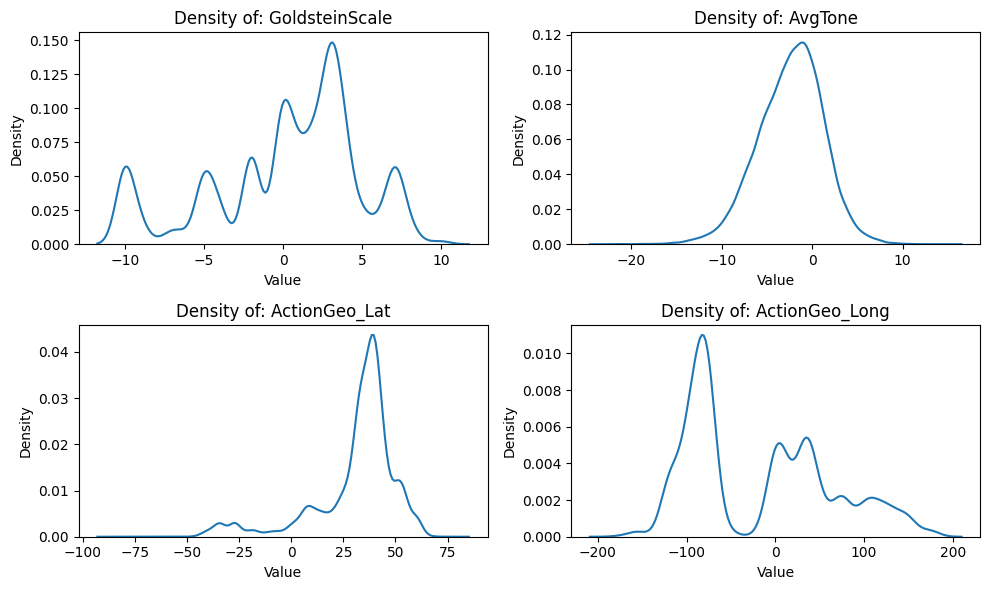

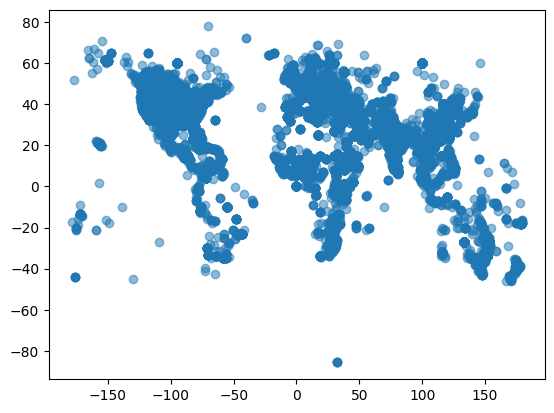

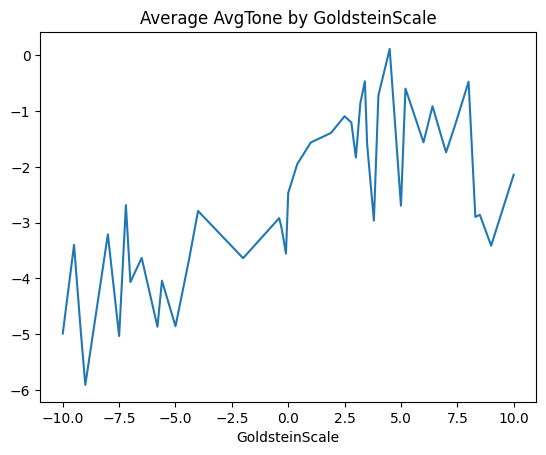

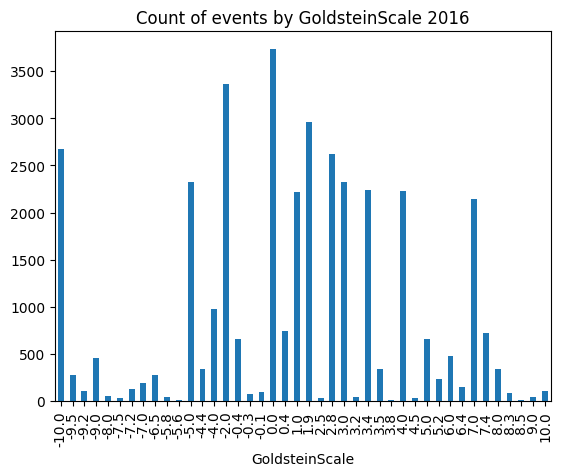

In [22]:
for year in range(2016, 2017):
    sample_df = pd.read_csv(f"gdelt_all_events_{year}_sample.csv", low_memory=False)

    features = [
        "GoldsteinScale", "AvgTone", "ActionGeo_Lat", "ActionGeo_Long"
    ]

    df2 = sample_df[features]

    fig, axes = plt.subplots(2, 2, figsize=(10, 6))
    axes = axes.flatten()

    for i, var in enumerate(features):
        data = df2[var].to_numpy()
        sns.kdeplot(data, ax=axes[i])
        axes[i].set_title(f"Density of: {var}")
        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Density")

    plt.tight_layout()
    plt.show()

    plt.scatter(df2["ActionGeo_Long"], df2["ActionGeo_Lat"], alpha=0.5)
    plt.show()

    df2.groupby("GoldsteinScale")["AvgTone"].mean().plot()
    plt.title("Average AvgTone by GoldsteinScale")
    plt.show()

    df2.groupby("GoldsteinScale")["AvgTone"].count().plot(kind='bar')
    # bar hist plot of count of events by GoldsteinScale
    plt.title("Count of events by GoldsteinScale " + str(year))
    plt.show()

In [23]:
# average AvgTone across years: barplot
for year in range(2016, 2026):
    df2 = pd.read_csv(f"gdelt_all_events_{year}_sample.csv", low_memory=False)
    print(f"Year {year} - Avg Tone in total: {df2['AvgTone'].mean():.2f} - Avg GoldsteinScale: {df2['GoldsteinScale'].mean():.2f} - Avg NumMentions: {df2['NumMentions'].mean():.2f} - Avg NumSources: {df2['NumSources'].mean():.2f} - Avg NumArticles: {df2['NumArticles'].mean():.2f}")

Year 2016 - Avg Tone in total: -2.39 - Avg GoldsteinScale: 0.29 - Avg NumMentions: 60.19 - Avg NumSources: 8.83 - Avg NumArticles: 57.83
Year 2017 - Avg Tone in total: -2.33 - Avg GoldsteinScale: 0.41 - Avg NumMentions: 59.49 - Avg NumSources: 9.47 - Avg NumArticles: 57.31
Year 2018 - Avg Tone in total: -2.38 - Avg GoldsteinScale: 0.38 - Avg NumMentions: 60.69 - Avg NumSources: 10.26 - Avg NumArticles: 58.47
Year 2019 - Avg Tone in total: -2.51 - Avg GoldsteinScale: 0.40 - Avg NumMentions: 49.49 - Avg NumSources: 8.66 - Avg NumArticles: 48.00
Year 2020 - Avg Tone in total: -2.46 - Avg GoldsteinScale: 0.56 - Avg NumMentions: 40.15 - Avg NumSources: 6.90 - Avg NumArticles: 38.94
Year 2021 - Avg Tone in total: -2.26 - Avg GoldsteinScale: 0.56 - Avg NumMentions: 34.10 - Avg NumSources: 5.78 - Avg NumArticles: 33.07
Year 2022 - Avg Tone in total: -2.27 - Avg GoldsteinScale: 0.47 - Avg NumMentions: 28.19 - Avg NumSources: 4.87 - Avg NumArticles: 27.32
Year 2023 - Avg Tone in total: -2.26 - A

## Space

In [24]:
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
gdf = gpd.read_file(url)
gdf.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,NaN,NaN,Unrecognized,NaN,NaN,NaN,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


In [25]:
# number of mentions by country
#map_df = sample_df.groupby("ActionGeo_CountryCode")["NumMentions"].sum().sort_values(ascending=False)
#map_df

In [26]:
# count na values in ActionGeo_CountryCode
sample_df["Actor2Geo_CountryCode"].isna().sum() / len(sample_df)

np.float64(0.33472677595628414)

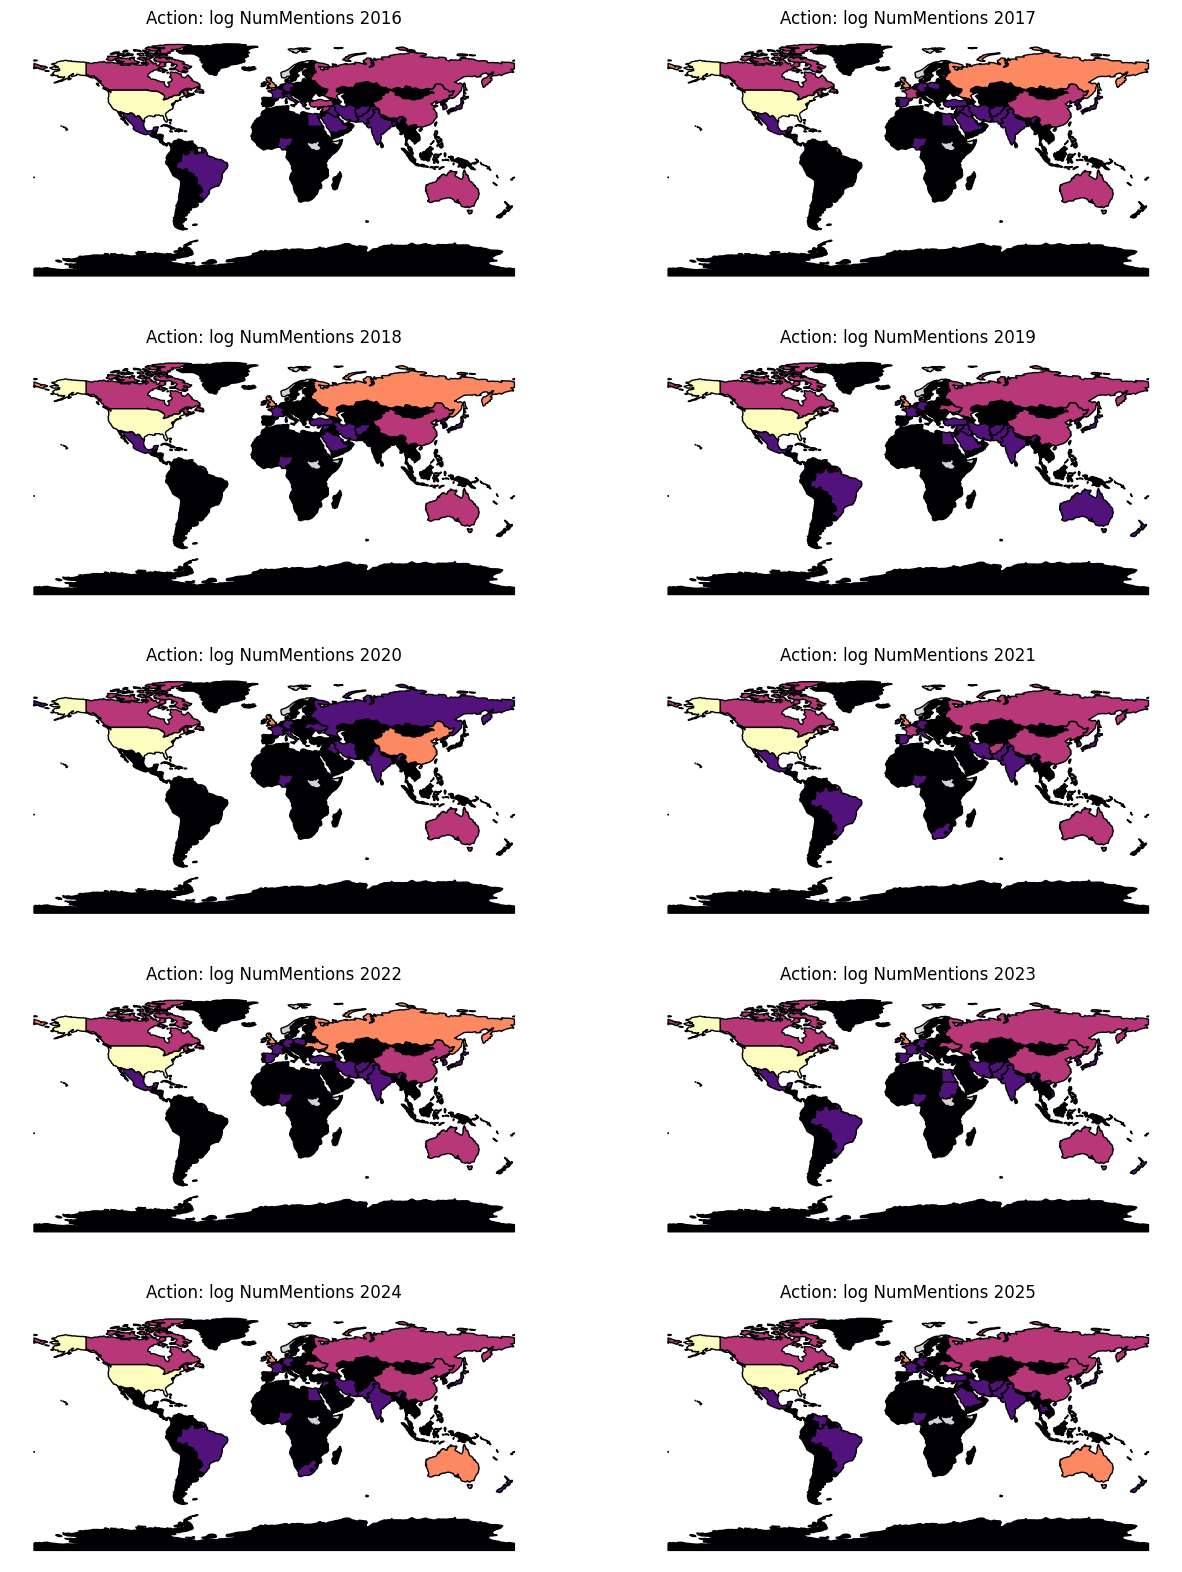

In [28]:
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
axes = axes.flatten()

for i, year in enumerate(range(2016, 2026)):
    ax = axes[i]
    sample_df = pd.read_csv(f"gdelt_all_events_{year}_sample.csv", low_memory=False)

    map_df = sample_df.groupby("Actor1Geo_CountryCode")["NumMentions"].sum().sort_values(ascending=False)

    merged = pd.merge(
            gdf,
            map_df,
            how="left",
            left_on="FIPS_10",
            right_index=True
        )
    merged["log_NumMentions"] = np.log1p(merged["NumMentions"])
    merged.plot(
            column="NumMentions",
            ax=ax,
            cmap="magma",
            edgecolor="black",
            scheme="naturalbreaks",
            k=5,
            legend=False,
            missing_kwds={"color": "lightgrey"}
        )
    
    ax.set_title(f"Action: log NumMentions " + str(year))
    ax.axis("off")

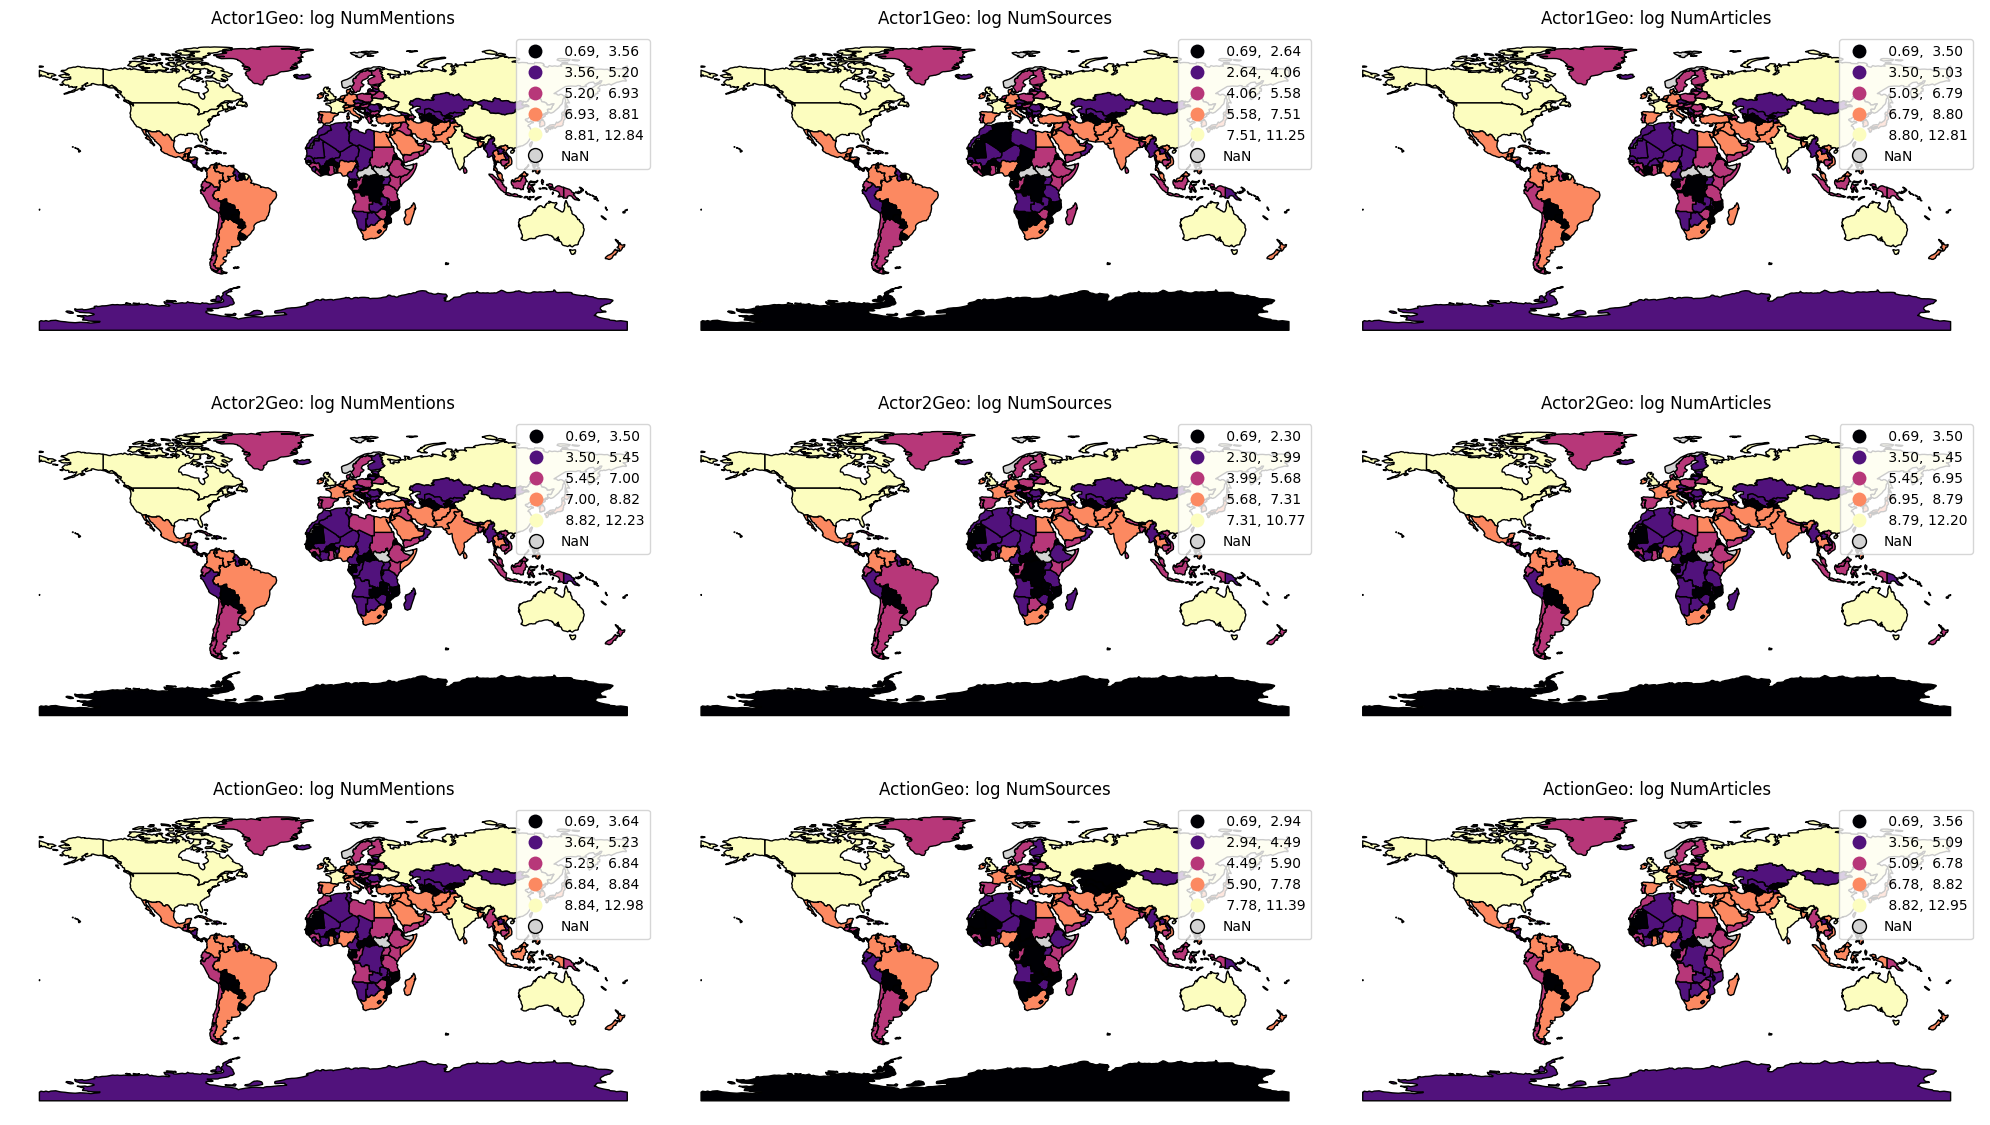

In [29]:
fig, axes = plt.subplots(3, 3, figsize=(20, 12))

geo_types = ["Actor1Geo", "Actor2Geo", "ActionGeo"]
columns = ["NumMentions", "NumSources", "NumArticles"]

for i, geo_type in enumerate(geo_types):
    for j, column in enumerate(columns):
        ax = axes[i, j]

        map_df = (
            sample_df
            .groupby(geo_type + "_CountryCode")[column]
            .sum()
            .sort_values(ascending=False)
        )

        merged = pd.merge(
            gdf,
            map_df,
            how="left",
            left_on="FIPS_10",
            right_index=True
        )

        merged["log_" + column] = np.log1p(merged[column])

        merged.plot(
            column="log_" + column,
            ax=ax,
            cmap="magma",
            edgecolor="black",
            scheme="naturalbreaks",
            k=5,
            legend=True,
            missing_kwds={"color": "lightgrey"}
        )

        ax.set_title(f"{geo_type}: log {column}")
        ax.axis("off")

plt.tight_layout()
plt.show()

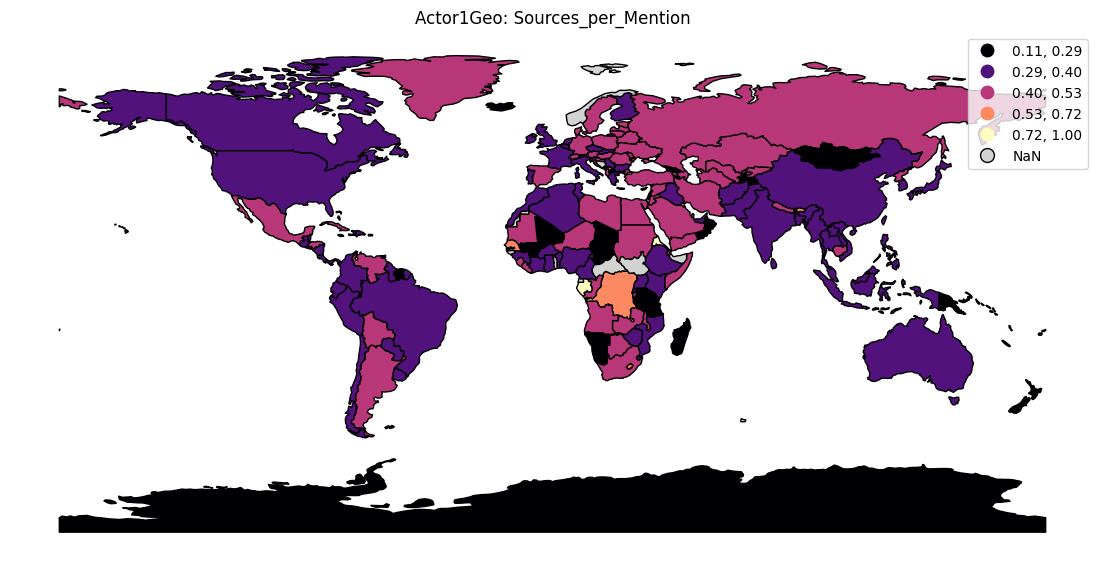

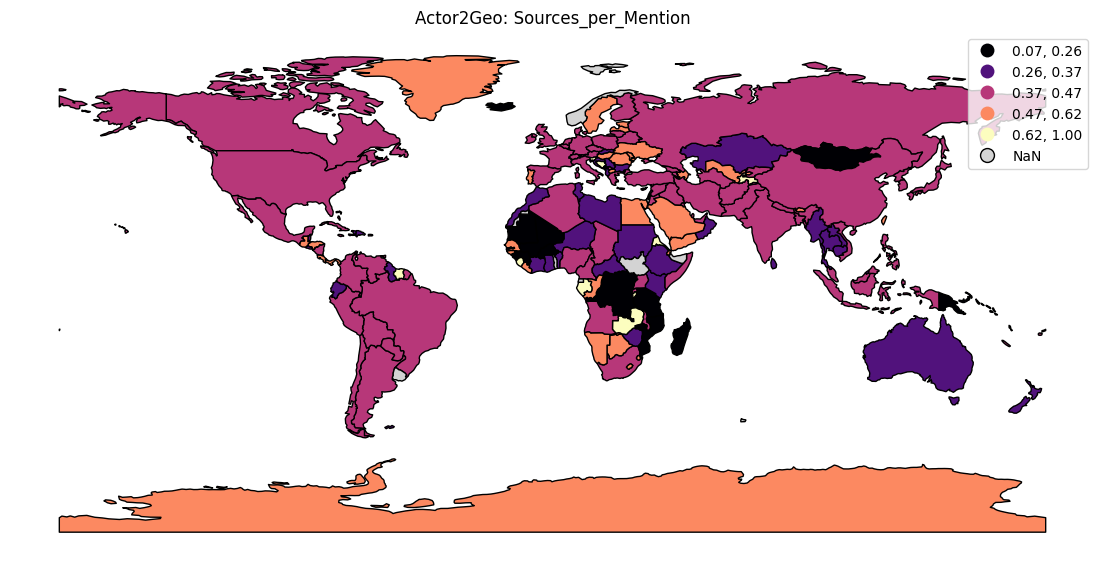

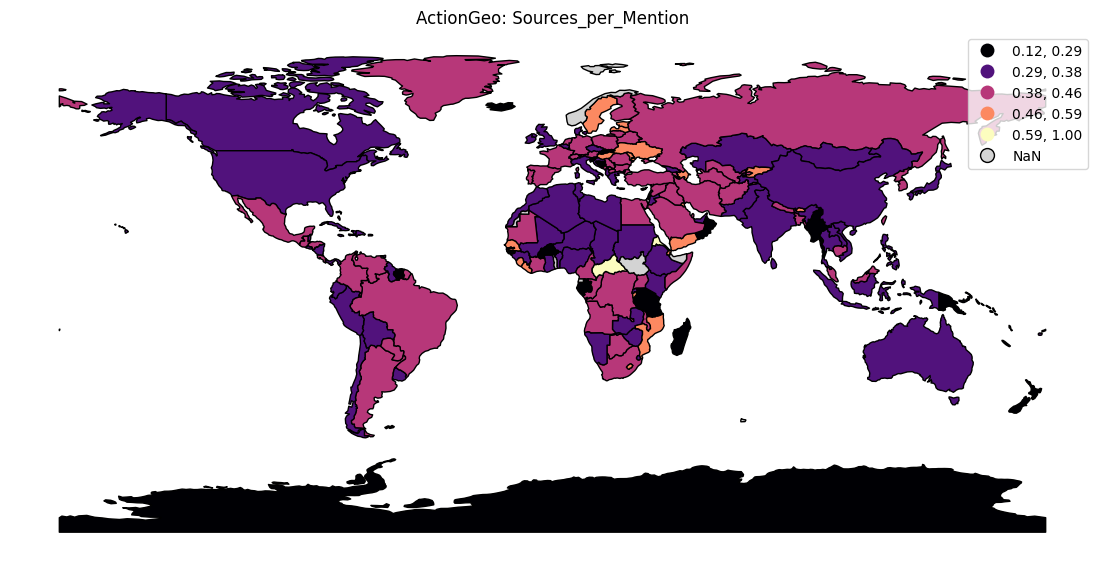

In [31]:
geo_types = ["Actor1Geo", "Actor2Geo", "ActionGeo"]
sample_df["Sources_per_Mention"] = sample_df["NumSources"] / sample_df["NumMentions"]
column = "Sources_per_Mention"

for geo_type in geo_types:
    map_df = (
        sample_df
        .groupby(f"{geo_type}_CountryCode")[column]
        .mean()
        .sort_values(ascending=False)
    )

    merged = pd.merge(
        gdf,
        map_df,
        how="left",
        left_on="FIPS_10",
        right_index=True
    )

    merged[f"log_{column}"] = np.log1p(merged[column])

    fig, ax = plt.subplots(figsize=(14, 7))

    merged.plot(
        column=column,
        ax=ax,
        cmap="magma",
        edgecolor="black",
        scheme="naturalbreaks",
        k=5,
        legend=True,
        missing_kwds={"color": "lightgrey"}
    )

    ax.set_title(f"{geo_type}: {column}")
    ax.axis("off")

    plt.show()

In [127]:
sample_df

,GlobalEventID,Day,MonthYear,Year,FractionDate,Actor1Code,Actor1Name,Actor1CountryCode,Actor1KnownGroupCode,Actor1EthnicCode,...,ActionGeo_Type,ActionGeo_FullName,ActionGeo_CountryCode,ActionGeo_ADM1Code,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL,Sources_per_Mention
0,1218374346,20250101,202501,2025,2025.0027,USA,UNITED STATES,USA,NaN,NaN,...,3,"Effingham County, Georgia, United States",US,USGA,32.3669,-81.333200,350219,20250101,https://www.firstcoastnews.com/article/news/lo...,0.312500
1,1218372092,20250101,202501,2025,2025.0027,NGA,NIGERIA,NGA,NaN,NaN,...,4,"Adamawa, Nigeria (general), Nigeria",NI,NI00,11.4833,10.966700,-1997189,20250101,https://thesun.ng/2024-telecom-sector-balances...,0.125000
2,1218368642,20250101,202501,2025,2025.0027,NaN,NaN,NaN,NaN,NaN,...,0,NaN,NaN,NaN,NaN,NaN,NaN,20250101,https://www.ewrestlingnews.com/news/wwe/photo-...,0.100000
3,1218372150,20250101,202501,2025,2025.0027,PSE,PALESTINIAN,PSE,NaN,NaN,...,3,"Washington, District of Columbia, United States",US,USDC,38.8951,-77.036400,531871,20250101,https://www.algemeiner.com/2024/12/31/top-pale...,1.000000
4,1218371929,20250101,202501,2025,2025.0027,GOV,PRESIDENT,NaN,NaN,NaN,...,2,"Iowa, United States",US,USIA,42.0046,-93.214000,IA,20250101,https://www.riponpress.com/news/year-in-review...,0.100000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34695,1281607144,20251231,202512,2025,2025.9890,CVL,RESIDENTS,NaN,NaN,NaN,...,0,NaN,NaN,NaN,NaN,NaN,NaN,20251231,https://www.el-balad.com/6807055,0.200000
34696,1281614774,20251231,202512,2025,2025.9890,NaN,NaN,NaN,NaN,NaN,...,4,"Beijing, Beijing, China",CH,CH22,39.9289,116.388000,-1898541,20251231,https://www.newkerala.com/news/o/after-trump-c...,0.102662
34697,1281612516,20251231,202512,2025,2025.9890,USA,UNITED STATES,USA,NaN,NaN,...,3,"Dawson County, Texas, United States",US,USTX,32.7334,-101.950000,1383843,20251231,https://nebraska.tv/news/local/tyson-plant-clo...,0.500000
34698,1281612230,20251231,202512,2025,2025.9890,LEG,LAWMAKER,NaN,NaN,NaN,...,2,"Virginia, United States",US,USVA,37.7680,-78.205700,VA,20251231,https://www.postregister.com/news/state/ballot...,0.200000


## Sampling and EDA of mentions

In [129]:
def make_gdelt_urls_sample(year, file_type="mentions"):
    dates = pd.date_range(
        start=f"{year}-01-01 00:00:00",
        end=f"{year}-12-31 23:45:00",
        freq="15min"
    ).to_list()
    sample_dates = random.sample(dates, 100)

    return [
        f"D:\\gdelt_data\\{year}_mentions\\{dt:%Y%m%d%H%M%S}.{file_type}.CSV.zip"
        for dt in sample_dates
    ]


In [ ]:
for year in range(2016, 2026):
    sample = make_gdelt_urls_sample(year)
    dfs = []

    for url in sample:
        try:
            df = pd.read_csv(url, compression='zip', header=None, sep='\t', low_memory=False)
        except Exception as e:
            print(f"Error reading {url}: {e}")
            continue
        dfs.append(df)

    total_df = pd.concat(dfs, ignore_index=True)
    total_df

    total_df.to_csv(f"mentions_samples//gdelt_mentions_sample_{year}.csv", index=False)

Error reading D:\gdelt_data\2016_mentions\20160929210000.mentions.CSV.zip: [Errno 2] No such file or directory: 'D:\\gdelt_data\\2016_mentions\\20160929210000.mentions.CSV.zip'
Error reading D:\gdelt_data\2017_mentions\20171119100000.mentions.CSV.zip: [Errno 2] No such file or directory: 'D:\\gdelt_data\\2017_mentions\\20171119100000.mentions.CSV.zip'
Error reading D:\gdelt_data\2017_mentions\20170710223000.mentions.CSV.zip: [Errno 2] No such file or directory: 'D:\\gdelt_data\\2017_mentions\\20170710223000.mentions.CSV.zip'
Error reading D:\gdelt_data\2017_mentions\20170611084500.mentions.CSV.zip: [Errno 2] No such file or directory: 'D:\\gdelt_data\\2017_mentions\\20170611084500.mentions.CSV.zip'
Error reading D:\gdelt_data\2017_mentions\20170701004500.mentions.CSV.zip: [Errno 2] No such file or directory: 'D:\\gdelt_data\\2017_mentions\\20170701004500.mentions.CSV.zip'
Error reading D:\gdelt_data\2018_mentions\20180228091500.mentions.CSV.zip: [Errno 2] No such file or directory: 'D:

In [36]:
total_df = pd.read_csv("gdelt_mentions_sample_2016.csv", low_memory=False)
mention_columns = ["GlobalEventID", "EventTimeDate", "MentionTimeDate", "MentionType", "MentionSourceName", "MentionIdentifier", "SentenceID", "Actor1CharOffset", "Actor2CharOffset", "ActionCharOffset", "InRawText", "Confidence", "MentionDocLen", "MentionDocTone", "MentionDocTranslationInfo", "Extras"]
total_df.columns = mention_columns
total_df.head()

,GlobalEventID,EventTimeDate,MentionTimeDate,MentionType,MentionSourceName,MentionIdentifier,SentenceID,Actor1CharOffset,Actor2CharOffset,ActionCharOffset,InRawText,Confidence,MentionDocLen,MentionDocTone,MentionDocTranslationInfo,Extras
0,519916512,20160311001500,20160311181500,1,nextgov.com,http://www.nextgov.com/defense/2016/03/all-fed...,6,1686,1788,1756,1,100,3125,-3.740157,NaN,NaN
1,520167789,20160311174500,20160311181500,1,hotelnewsnow.com,http://hotelnewsnow.com/articles/32631/STR-Pre...,2,-1,681,696,1,100,2240,-0.983607,NaN,NaN
2,416280467,20150312000000,20160311181500,1,delawareonline.com,http://www.delawareonline.com/story/news/local...,1,-1,430,630,1,100,2468,-2.450980,NaN,NaN
3,519910265,20160311000000,20160311181500,1,asianuniverse.net,http://asianuniverse.net/forums/index.php?s=d1...,7,-1,2326,2221,0,40,9298,0.781250,NaN,NaN
4,416577764,20150312210000,20160311181500,1,asianuniverse.net,http://asianuniverse.net/forums/index.php?s=d1...,7,-1,2308,2221,0,20,9298,0.781250,NaN,NaN


## Density plots

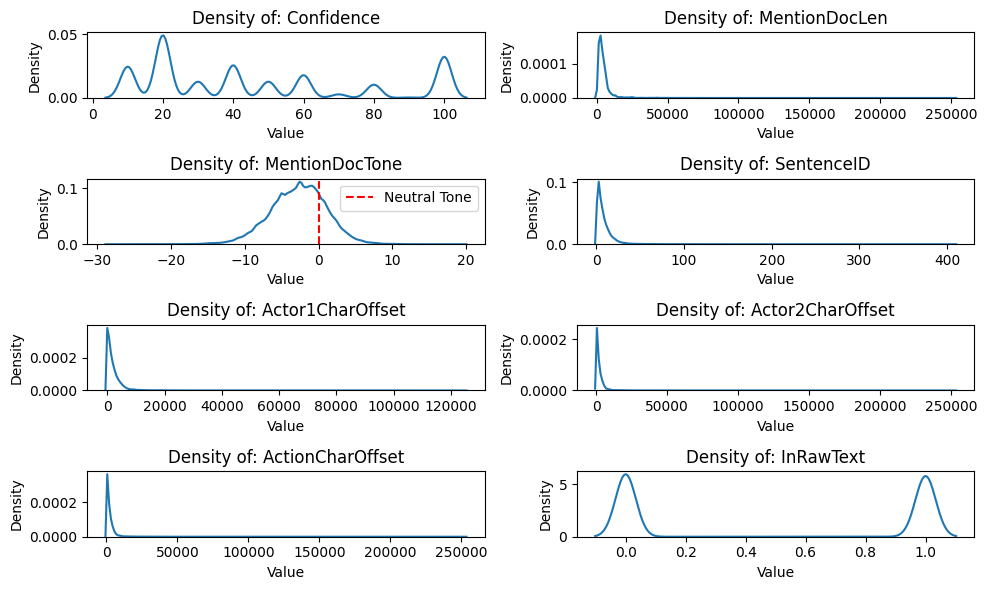

In [47]:
cols = ["Confidence", "MentionDocLen", "MentionDocTone", "SentenceID", "Actor1CharOffset", "Actor2CharOffset", "ActionCharOffset", "InRawText"]

df2 = total_df[cols]

fig, axes = plt.subplots(4, 2, figsize=(10, 6))
axes = axes.flatten()

for i, var in enumerate(cols):
    data = df2[var].to_numpy()
    sns.kdeplot(data, ax=axes[i])
    axes[i].set_title(f"Density of: {var}")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Density")
    if var == "MentionDocTone":
        axes[i].axvline(0, color='red', linestyle='--', label='Neutral Tone')
        axes[i].legend()

plt.tight_layout()
plt.show()


In [51]:
len(total_df[total_df["Confidence"] >= 90])

119939

In [50]:
len(total_df)

691709

In [55]:
# cluster the "confidence" column:
total_df["ConfidenceCluster"], bins = pd.qcut(
    total_df["Confidence"],
    q=5,
    labels=False,
    retbins=True
)

print(bins)

[ 10.  20.  30.  50.  80. 100.]


## Distribution of failed Download files

Findings:
- No apparent connection between the weekday and likelihood of files missing
- Files covering night / early morning more likely to be missing
- high proportion of missing files in 2020 and 2025
- especially 2020-10, 2020-11, 2025-06 have over 40% missing mention files respectively -> how to handle this?
- Spike in missing files in the middle of the month 

In [4]:
with open("failed_files.txt", "r") as f:
    failed_files = f.read().splitlines()
failed_files = [f[:14] for f in failed_files]

In [5]:
ff_df = pd.DataFrame(failed_files, columns=["FailedFile"])
ff_df["Year"] = [int(f[:4]) for f in ff_df["FailedFile"]]
#ff_df["Date"] = pd.to_datetime(ff_df["FailedFile"].str[:8], format='%Y%m%d').dt.date
ff_df["Weekday"] = pd.to_datetime(ff_df["FailedFile"].str[:8], format='%Y%m%d').dt.day_name()
ff_df["Time"] = pd.to_datetime(ff_df["FailedFile"].str[8:14], format='%H%M%S').dt.time
ff_df["Day"] = pd.to_datetime(ff_df["FailedFile"].str[:8], format='%Y%m%d').dt.day
ff_df["MonthYear"] = pd.to_datetime(ff_df["FailedFile"].str[:8], format='%Y%m%d').dt.to_period('M')
ff_df.head()

,FailedFile,Year,Weekday,Time,Day,MonthYear
0,20160107203000,2016,Thursday,20:30:00,7,2016-01
1,20160108014500,2016,Friday,01:45:00,8,2016-01
2,20160112014500,2016,Tuesday,01:45:00,12,2016-01
3,20160112001500,2016,Tuesday,00:15:00,12,2016-01
4,20160122013000,2016,Friday,01:30:00,22,2016-01


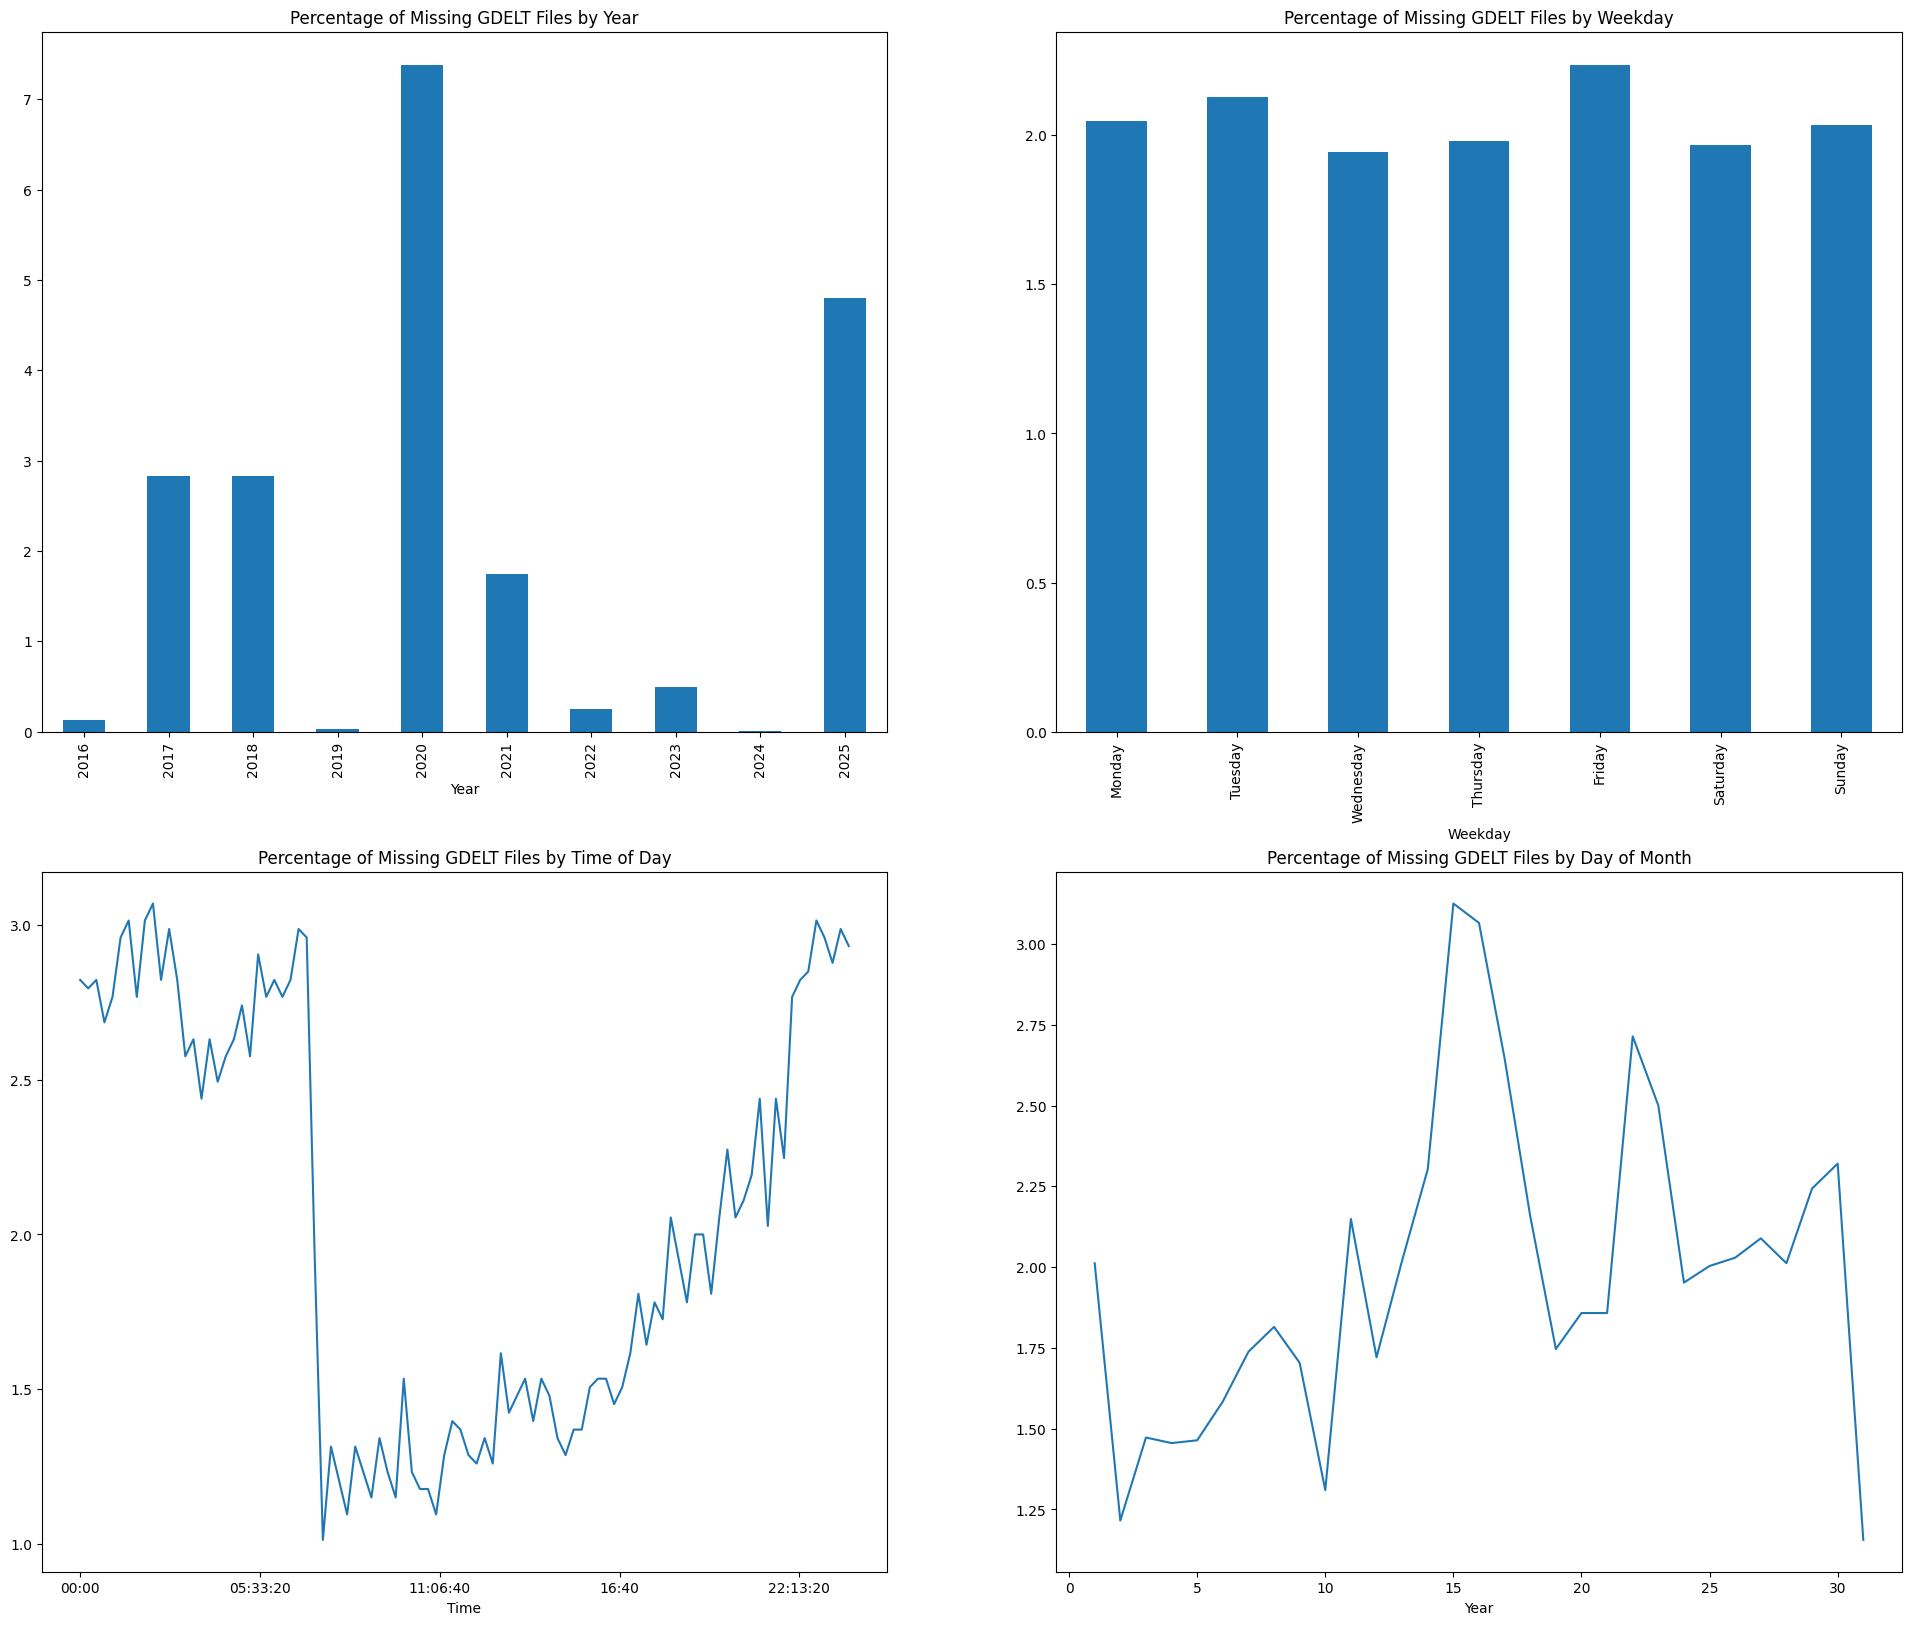

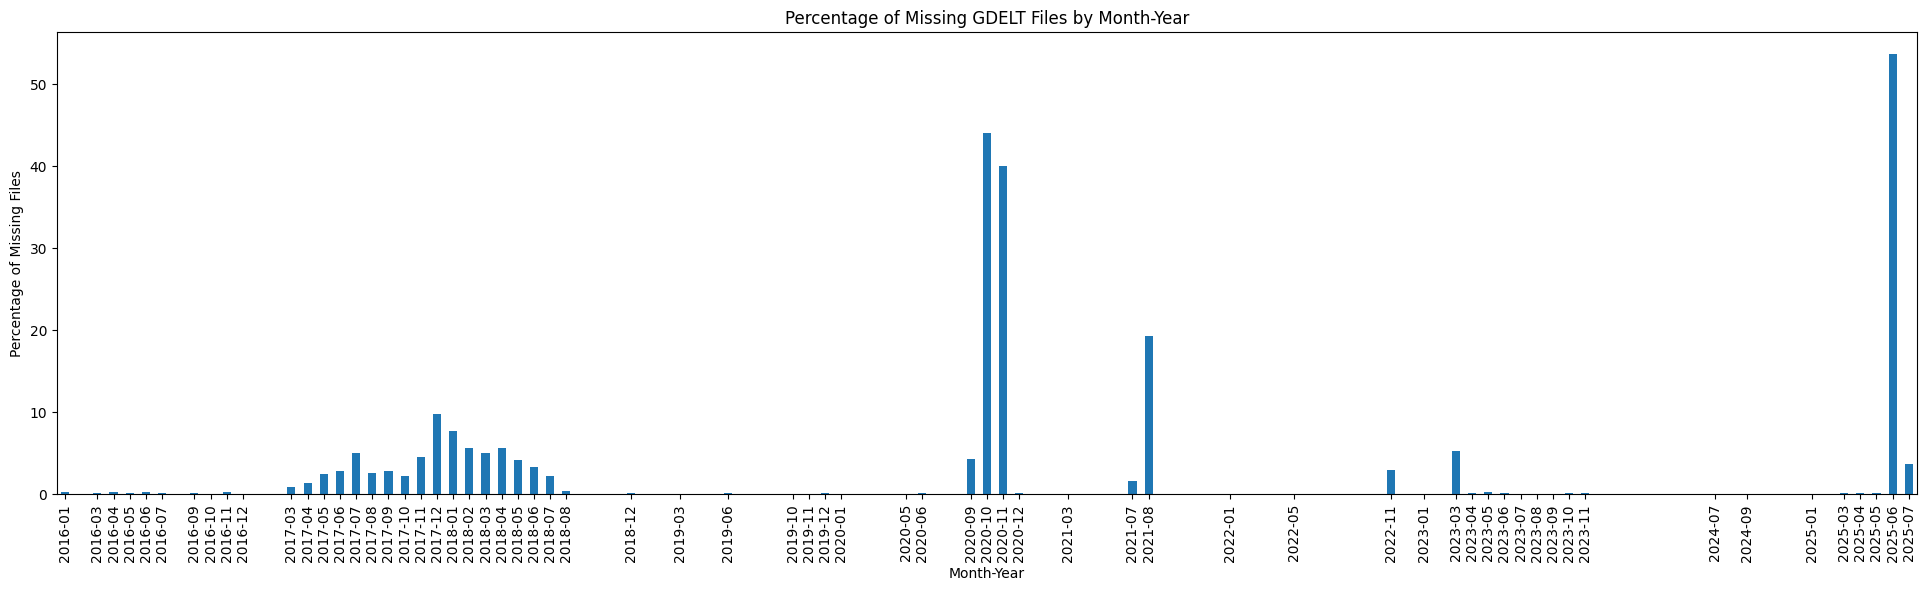

In [7]:
n_files = 350_400
fig, ax = plt.subplots(2 , 2, figsize=(24, 20))
ax = ax.flatten()

(ff_df.groupby("Year").size() / (n_files  / 1000)).plot(kind='bar', ax=ax[0], title="Percentage of Missing GDELT Files by Year") # sort by year:
(ff_df.groupby("Time").size() / (n_files  / 9600)).sort_index().plot(ax=ax[2], title="Percentage of Missing GDELT Files by Time of Day") # sort by time of day:
#ff_df.groupby("Day").size().sort_index().plot(kind='bar',ax=ax[1]) # sort by date:
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]
(ff_df.groupby("Weekday").size() / (n_files  / 700)).reindex(weekday_order).plot(kind='bar', ax=ax[1], title="Percentage of Missing GDELT Files by Weekday") # get weekday name from number:

#(ff_df.groupby("MonthYear").size() / (n_files *100 / 120)).sort_index().plot(ax=ax[3]) # sort by month-year:
(ff_df.groupby("Day").size() / (n_files  / 3000)).sort_index().plot(ax=ax[3], title="Percentage of Missing GDELT Files by Day of Month") # sort by day of month:

plt.xlabel("Year")
plt.show()

plt.figure(figsize=(24, 6))
(ff_df.groupby("MonthYear").size() / (n_files / 12000)).sort_index().plot(kind='bar',ax=plt.gca()) # sort by date:
plt.title("Percentage of Missing GDELT Files by Month-Year")
plt.xlabel("Month-Year")
plt.ylabel("Percentage of Missing Files")
plt.show()


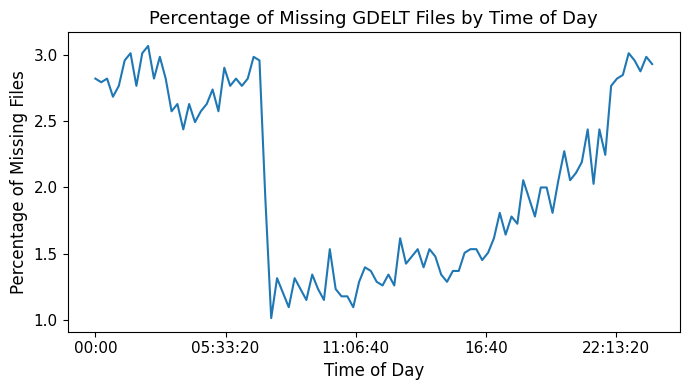

In [11]:
(
    ff_df.groupby("Time").size() / (n_files / 9600)
).sort_index().plot(
    figsize=(7, 4),
    title="Percentage of Missing GDELT Files by Time of Day",
    fontsize=11
)

plt.xlabel("Time of Day", fontsize=12)
plt.ylabel("Percentage of Missing Files", fontsize=12)
plt.title("Percentage of Missing GDELT Files by Time of Day", fontsize=13)

plt.tight_layout()
plt.show() # sort by time of day: